# Predicting Students' Academic Success using Artificial Intelligence Technology 

## Daragh Brady(D00255640), Ines Comeron(D00262824)

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Data Loading

In [2]:
df = pd.read_csv("data.csv", sep=";") #values were separated with semicolon instead of comma
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


## Dependent variable

In [3]:
#the dependent variable is "Target", whetehr the student has graduated, dropped out or is still enrolled after the standard/expected duration of a course
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

# Data Cleaning

## Missing value analysis

In [4]:
df.isnull().sum().sort_values(ascending=False)

#the data is not missing any variables

Marital status                                    0
Age at enrollment                                 0
Curricular units 1st sem (credited)               0
Curricular units 1st sem (enrolled)               0
Curricular units 1st sem (evaluations)            0
Curricular units 1st sem (approved)               0
Curricular units 1st sem (grade)                  0
Curricular units 1st sem (without evaluations)    0
Curricular units 2nd sem (credited)               0
Curricular units 2nd sem (enrolled)               0
Curricular units 2nd sem (evaluations)            0
Curricular units 2nd sem (approved)               0
Curricular units 2nd sem (grade)                  0
Curricular units 2nd sem (without evaluations)    0
Unemployment rate                                 0
Inflation rate                                    0
GDP                                               0
International                                     0
Scholarship holder                                0
Application 

The dataset has already been cleaned so data cleaning does not need to be performed

## Column renaming

In [5]:
#remove apostrophes since they complicate column referencing
df.columns = df.columns.str.replace("'", "", regex=False)
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mothers qualification', 'Fathers qualification', 'Mothers occupation',
       'Fathers occupation', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade

# Exploratory Data Analysis

In [6]:
df.shape

(4424, 37)

In [7]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mothers qualification', 'Fathers qualification', 'Mothers occupation',
       'Fathers occupation', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade

In [8]:
# since the main purpose of the dataset is to identify students likely to drop out, a dataframe containing only the students that dropped out will be created.
dropout = df['Target'] == 'Dropout'
df_dropout = df[dropout]
df_dropout

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout
12,1,1,2,9853,1,1,133.0,1,19,37,...,0,6,0,0,0.000000,0,12.7,3.7,-1.70,Dropout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4408,2,39,1,9773,1,1,100.0,1,37,37,...,0,6,10,6,11.666667,0,12.7,3.7,-1.70,Dropout
4411,1,44,1,9130,1,39,150.0,1,37,37,...,0,6,11,3,13.333333,0,13.9,-0.3,0.79,Dropout
4415,4,39,1,9500,1,19,133.1,1,37,37,...,0,7,12,3,11.083333,0,11.1,0.6,2.02,Dropout
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout


In [9]:
df_dropout.columns

#the columns can be categorized as follows: personal information, application information, financial information, academic performance and external factors

personal = ['Marital status', 'Nacionality', 'Mothers qualification', 'Fathers qualification', 'Mothers occupation', 'Fathers occupation', 'Displaced', 'Educational special needs', 'Gender', 'Age at enrollment', 'International']
application = ['Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Admission grade']
financial = ['Tuition fees up to date', 'Scholarship holder', 'Debtor']
academic = ['Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']
external = ['Unemployment rate', 'Inflation rate', 'GDP']

## EDA of personal information 

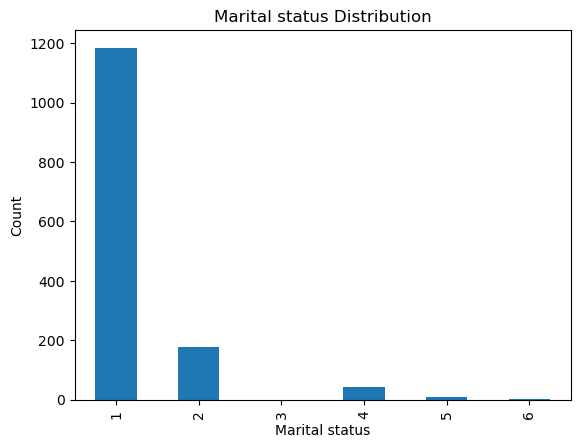

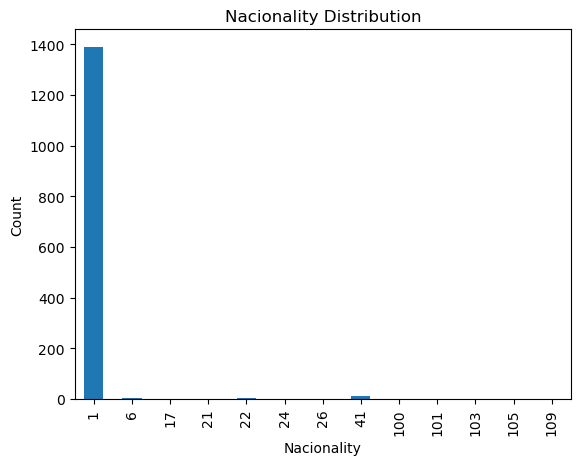

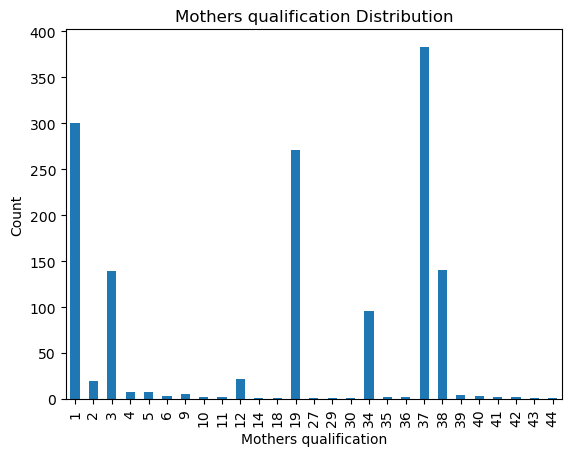

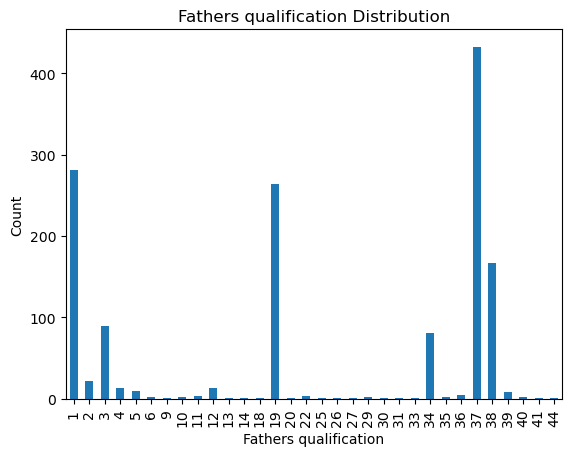

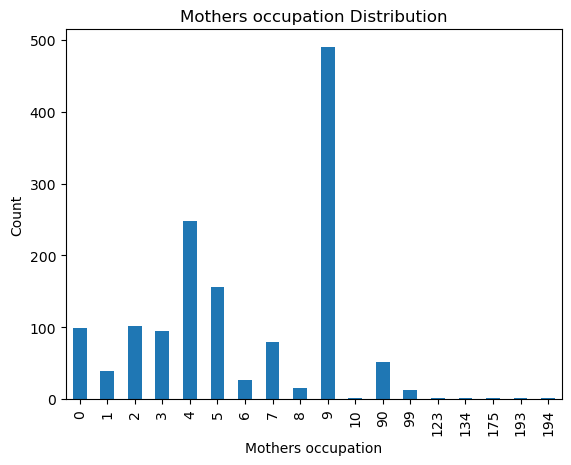

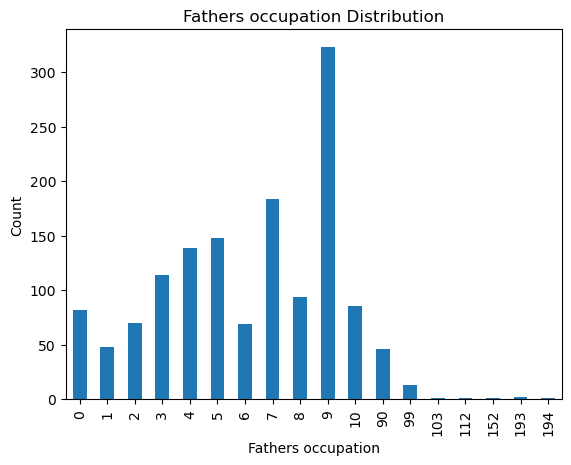

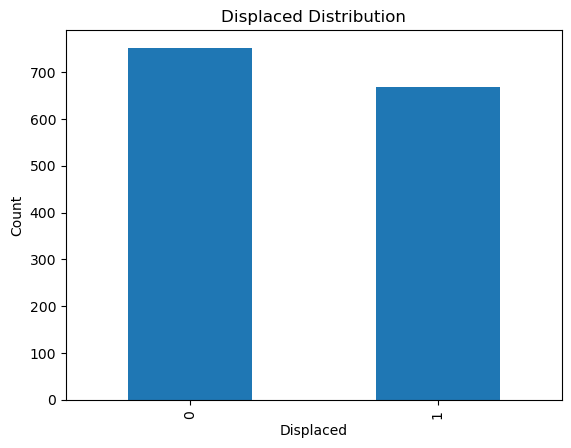

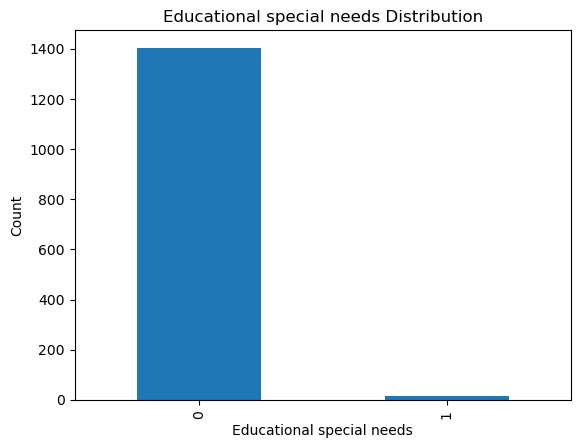

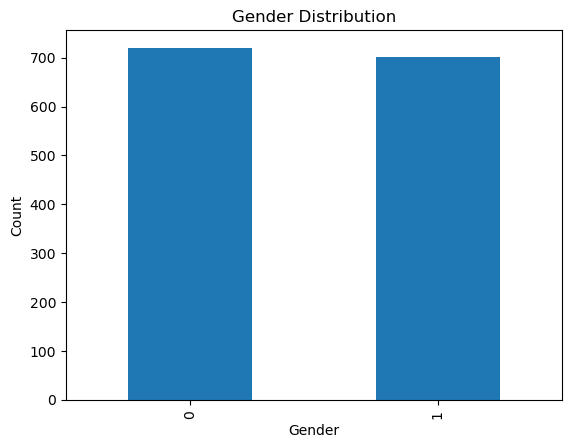

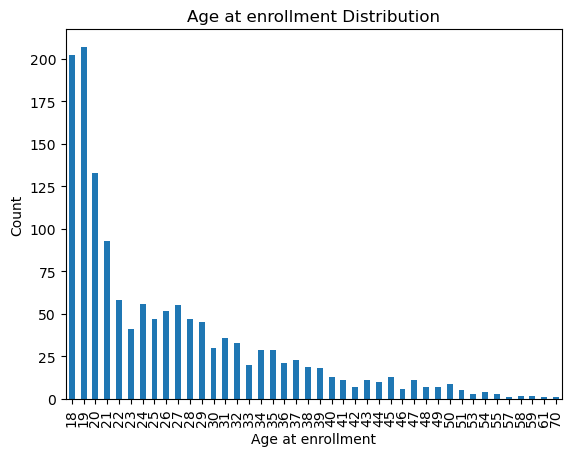

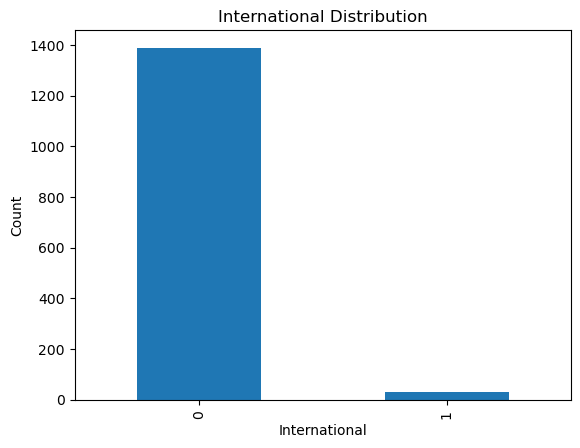

In [10]:
for feature in personal:
    df_dropout[feature].value_counts().sort_index().plot(kind='bar')
    
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'{feature} Distribution')
    
    plt.show()

## EDA of application information 

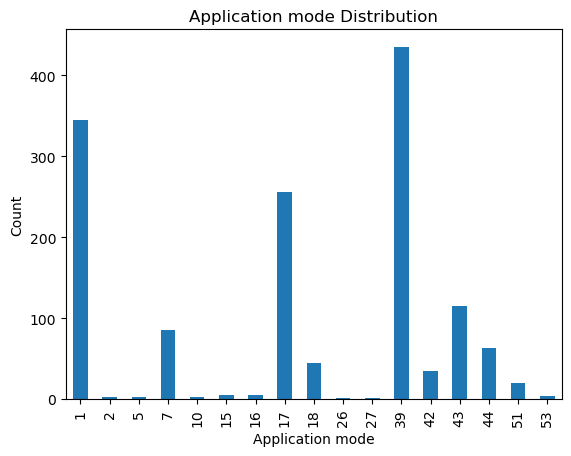

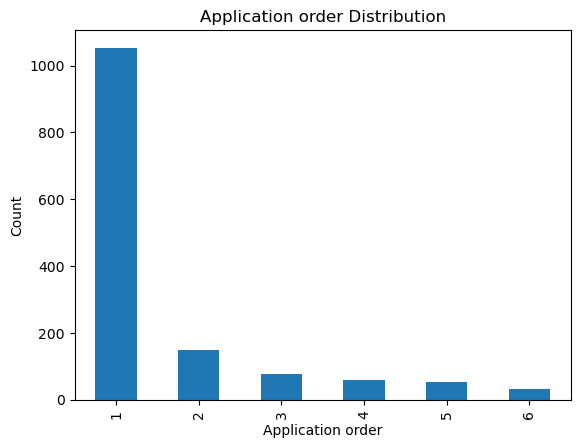

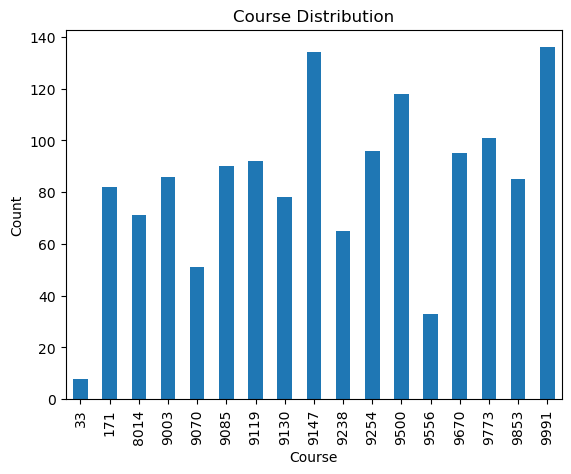

C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


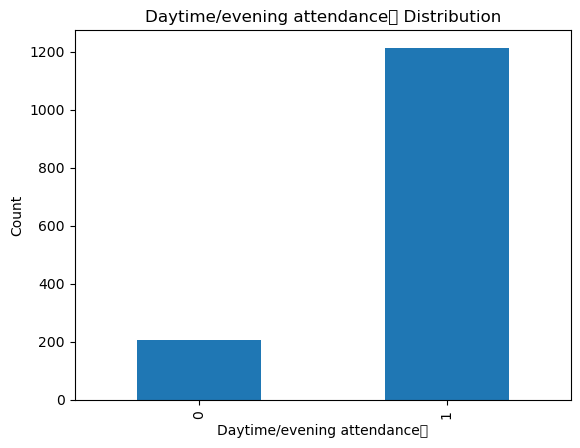

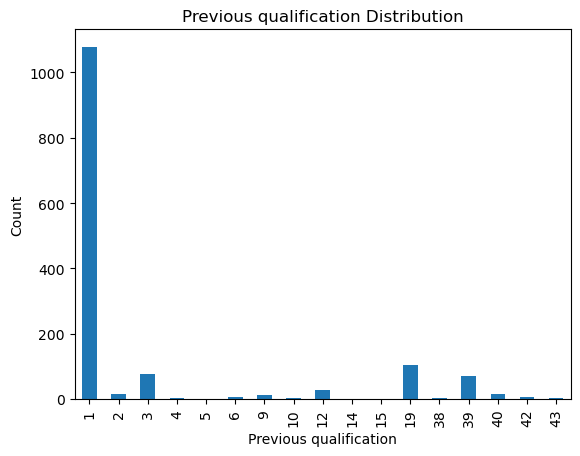

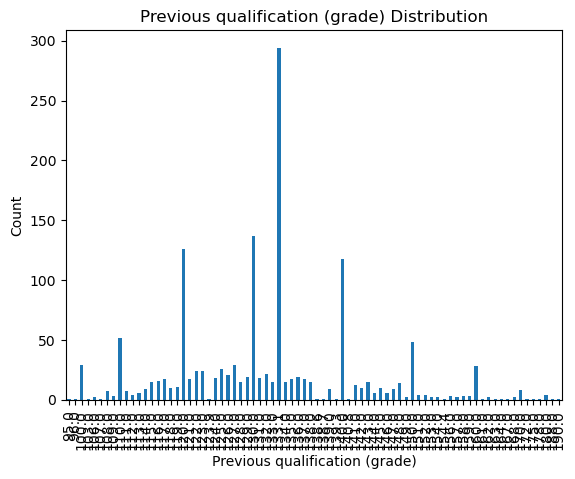

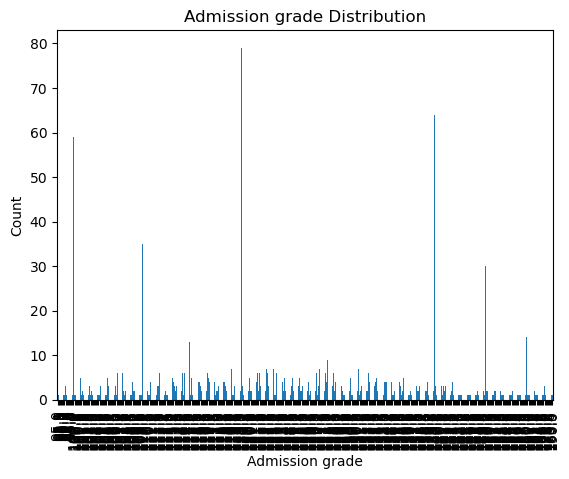

In [11]:
for feature in application:
    df_dropout[feature].value_counts().sort_index().plot(kind='bar')
    
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'{feature} Distribution')
    
    plt.show()

## EDA of financial information 

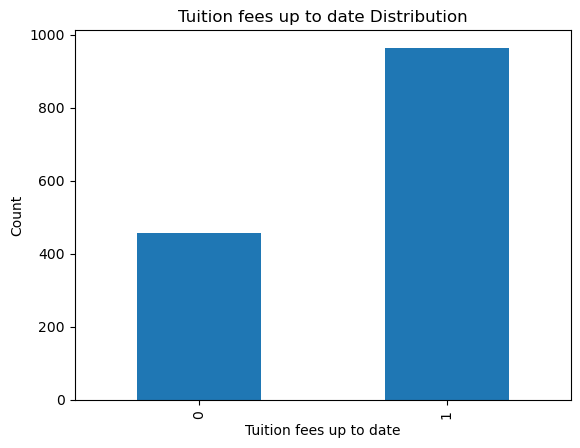

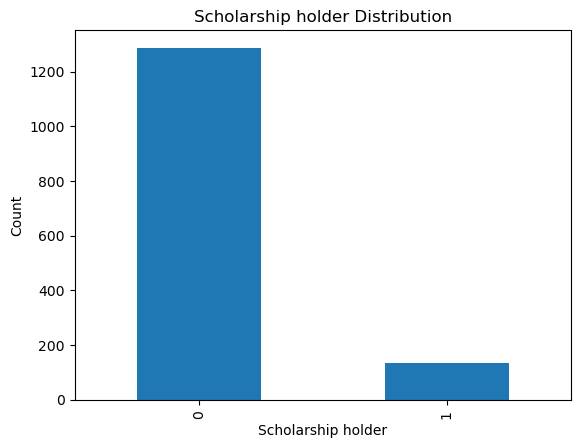

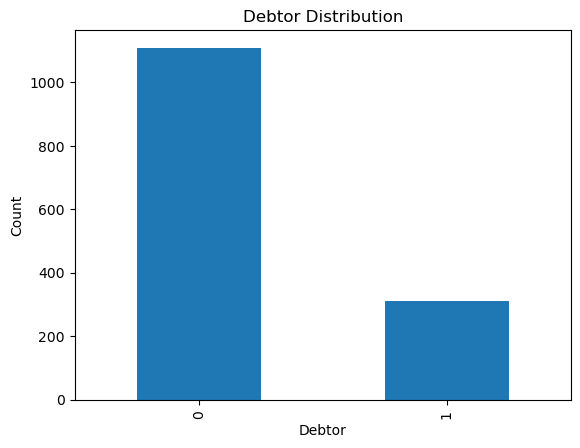

In [12]:
for feature in financial:
    df_dropout[feature].value_counts().sort_index().plot(kind='bar')
    
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'{feature} Distribution')
    
    plt.show()

## EDA of academic performance 

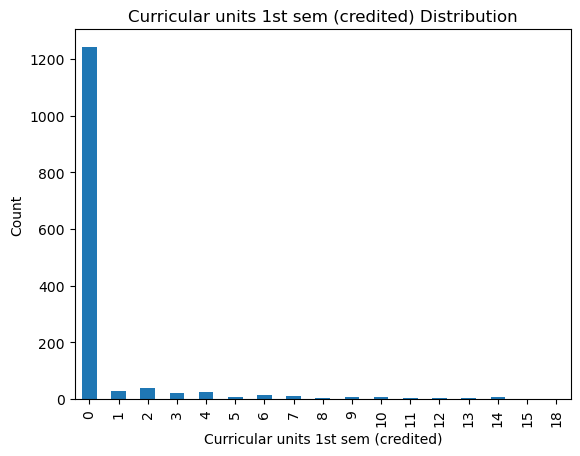

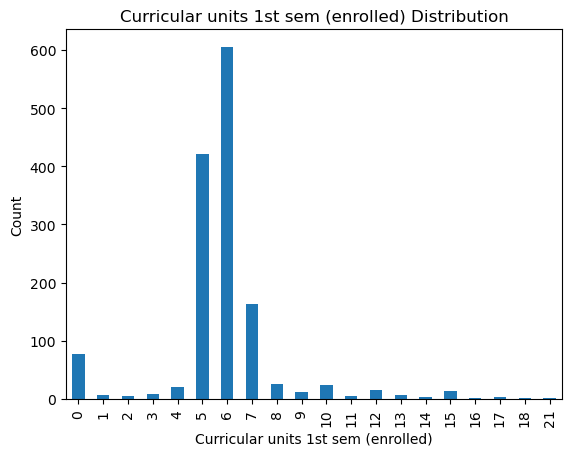

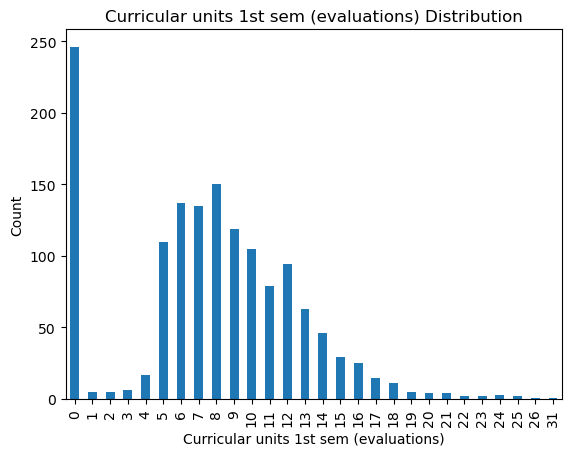

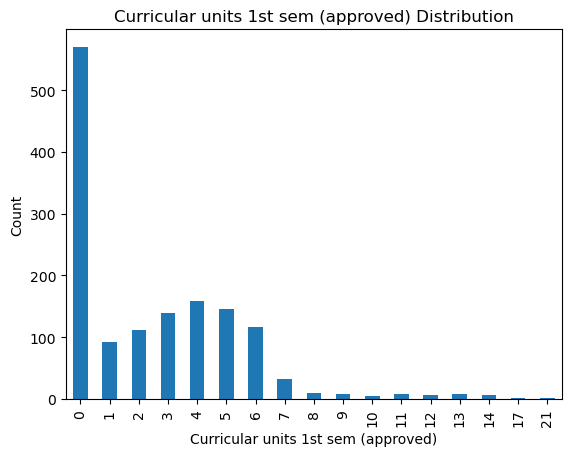

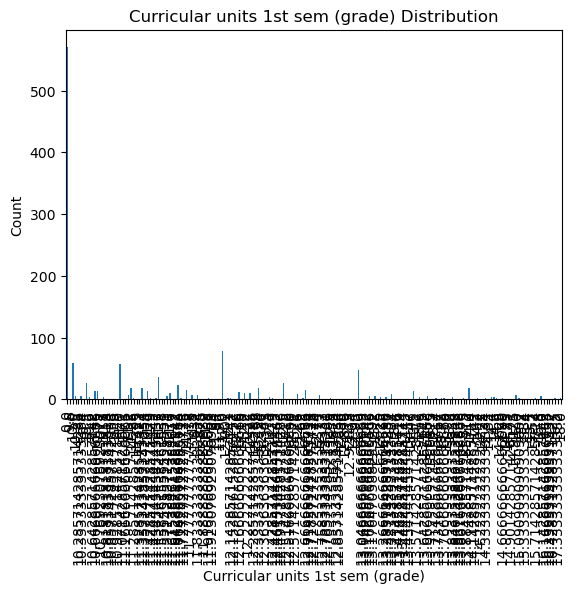

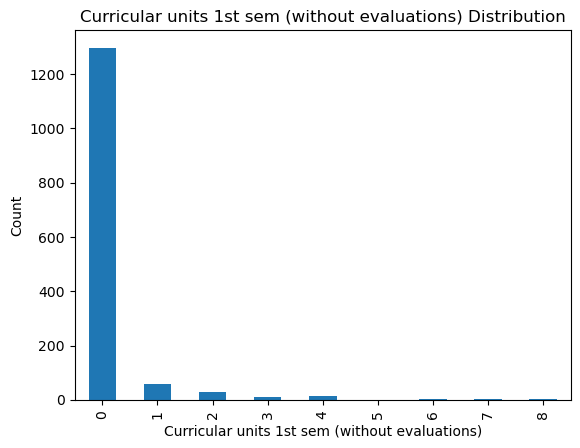

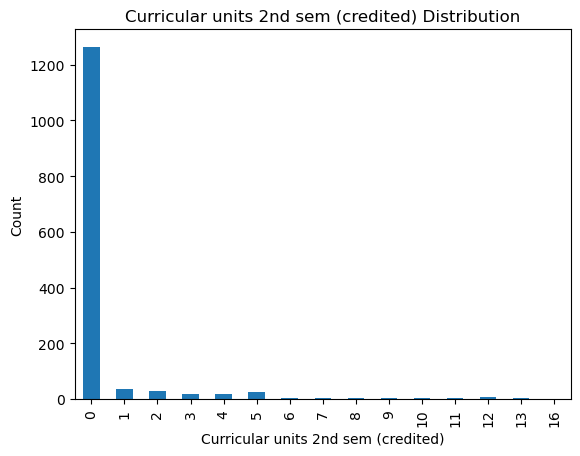

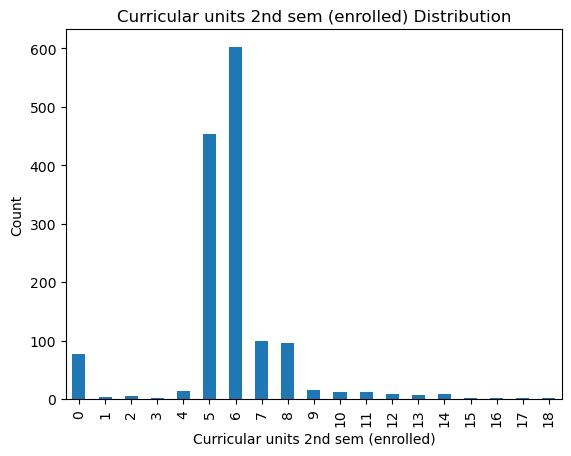

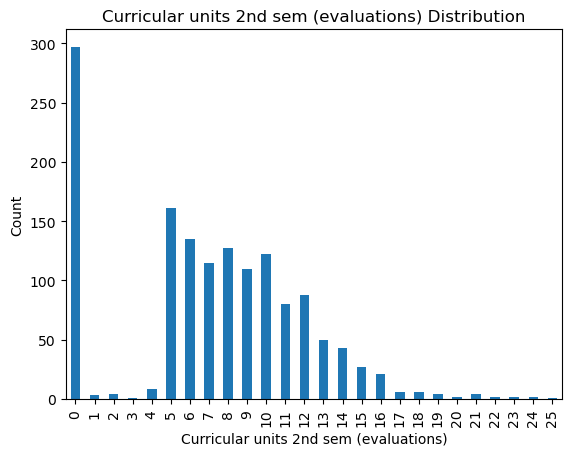

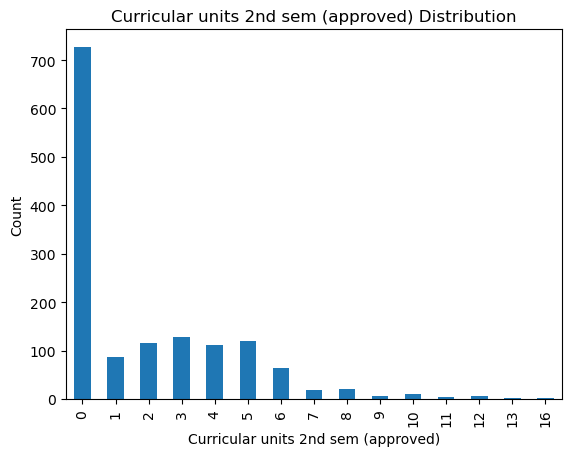

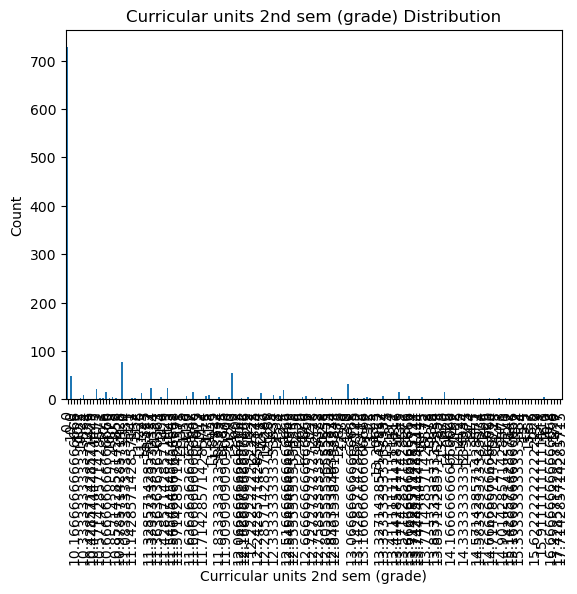

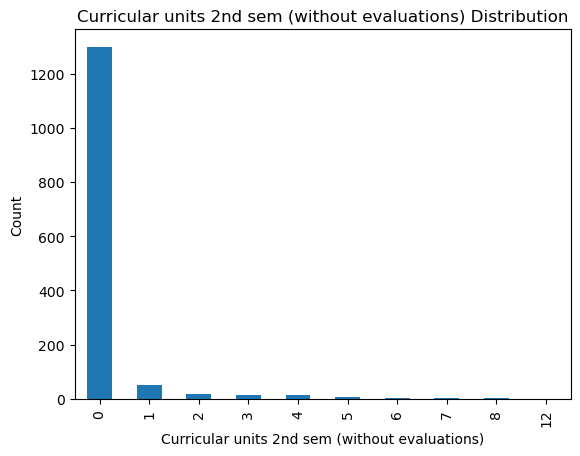

In [13]:
for feature in academic:
    df_dropout[feature].value_counts().sort_index().plot(kind='bar')
    
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'{feature} Distribution')
    
    plt.show()

## EDA of external factors 

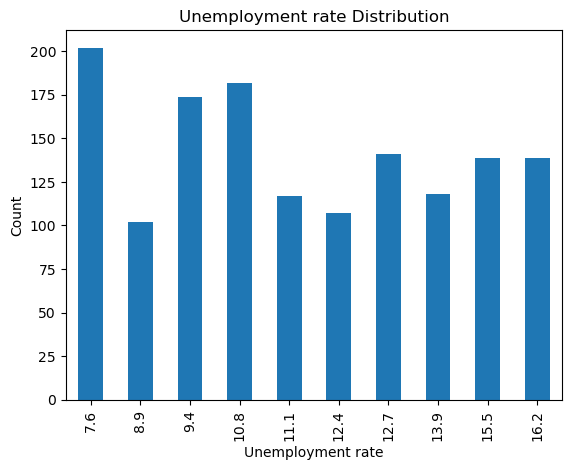

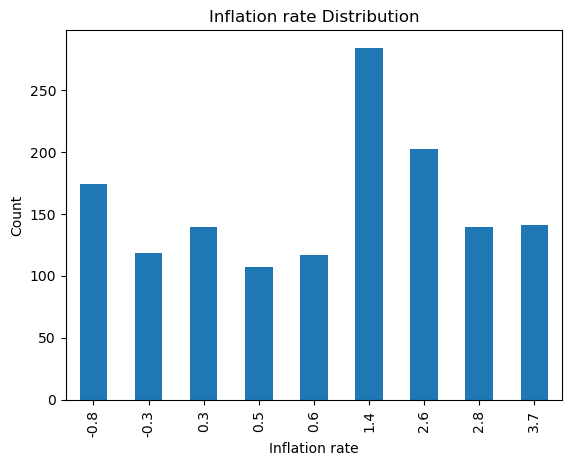

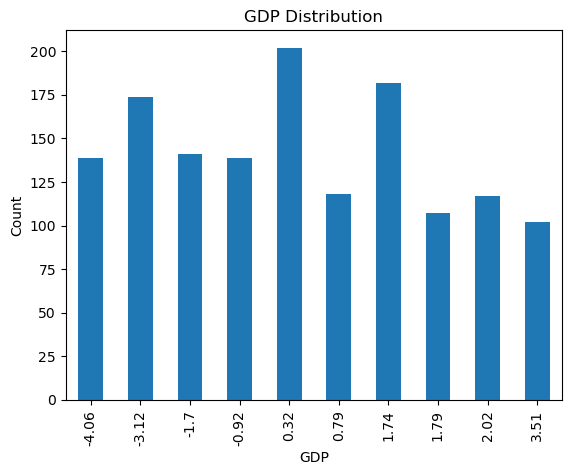

In [14]:
for feature in external:
    df_dropout[feature].value_counts().sort_index().plot(kind='bar')
    
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'{feature} Distribution')
    
    plt.show()

# Feature engineering

## Convert values with one-hot encoding

In [15]:
df.dtypes

#all columns except target variable are numeric

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mothers qualification                               int64
Fathers qualification                               int64
Mothers occupation                                  int64
Fathers occupation                                  int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [16]:
#convert target column to numeric using one-hot encoding

df['Target'].unique()

df['Target'] = df['Target'].astype('category').cat.codes 

In [17]:
# course variable is numeric but the numbers are technically categorical (represesting course numbers) so they are converted with one-hot encoding
df['Course'].unique()

df['Course'] = df['Course'].astype('category').cat.codes 

df['Course'].unique()



array([ 1, 10,  4, 14,  2, 16, 11,  9, 13, 15,  5,  7, 12,  8,  3,  0,  6],
      dtype=int8)

## Multicolinearity

C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


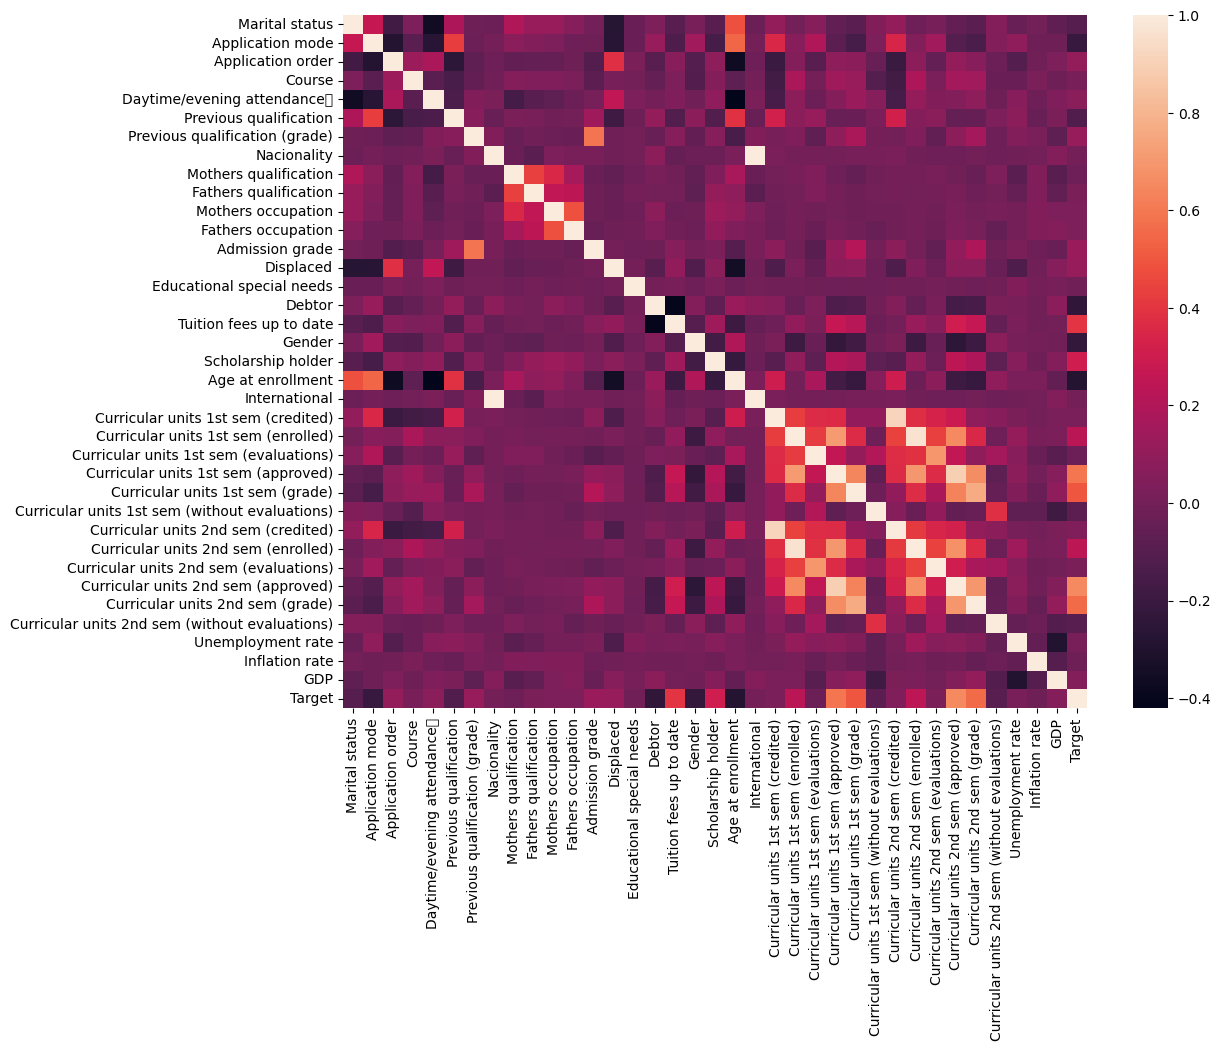

In [18]:
corrmat = df.corr(method="spearman")
f, ax = plt.subplots(figsize=(12, 9))
corrmat
sns.heatmap(corrmat, xticklabels=True, yticklabels=True);

In [19]:
corrmat

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
Marital status,1.000000,0.270338,-0.173570,0.031889,-0.357320,0.188576,-0.022017,-0.029930,0.192536,0.122113,...,0.101563,-0.020163,0.008579,-0.059403,-0.086094,0.056322,-0.038433,-0.000227,-0.068372,-0.103578
Application mode,0.270338,1.000000,-0.285442,-0.087354,-0.268726,0.423540,-0.028849,0.003433,0.069391,0.045777,...,0.343836,0.045705,0.149757,-0.104197,-0.139767,0.050885,0.090526,-0.025531,-0.021415,-0.214098
Application order,-0.173570,-0.285442,1.000000,0.133497,0.181484,-0.252829,-0.070509,-0.020345,-0.058330,-0.049272,...,-0.200700,0.074618,-0.053330,0.106065,0.065177,-0.030225,-0.104282,-0.010957,0.029774,0.102185
Course,0.031889,-0.087354,0.133497,1.000000,-0.087342,-0.144830,-0.055886,-0.004301,0.052636,0.035973,...,-0.165152,0.187852,0.018168,0.157075,0.146123,-0.032218,-0.035712,0.026073,-0.025193,0.014122
Daytime/evening attendance\t,-0.357320,-0.268726,0.181484,-0.087342,1.000000,-0.136938,0.043863,0.027889,-0.163797,-0.093102,...,-0.158831,0.109117,0.045418,0.045878,0.085519,-0.023491,0.062503,-0.016189,0.039652,0.073066
Previous qualification,0.188576,0.423540,-0.252829,-0.144830,-0.136938,1.000000,0.067735,-0.041196,0.026148,0.014766,...,0.314204,0.055023,0.072204,-0.052453,-0.044052,0.033168,0.082488,-0.041972,0.028250,-0.125939
Previous qualification (grade),-0.022017,-0.028849,-0.070509,-0.055886,0.043863,0.067735,1.000000,0.042412,-0.038054,-0.009190,...,-0.001368,0.036037,-0.061298,0.081666,0.152986,-0.016295,0.048137,0.019191,-0.072473,0.112414
Nacionality,-0.029930,0.003433,-0.020345,-0.004301,0.027889,-0.041196,0.042412,1.000000,-0.035231,-0.084564,...,0.019440,-0.007513,-0.016454,-0.015640,-0.002532,-0.017764,-0.010898,-0.003127,0.053882,0.002535
Mothers qualification,0.192536,0.069391,-0.058330,0.052636,-0.163797,0.026148,-0.038054,-0.035231,1.000000,0.434072,...,0.006391,0.004251,0.012539,-0.008952,-0.040858,0.031811,-0.087153,0.042042,-0.088526,-0.018999
Fathers qualification,0.122113,0.045777,-0.049272,0.035973,-0.093102,0.014766,-0.009190,-0.084564,0.434072,1.000000,...,0.003223,-0.003347,0.006204,0.014971,-0.016656,-0.001156,-0.048051,0.039591,-0.061781,0.024058


In [20]:
#drop colinear variables
df = df.drop('Nacionality', axis=1) #high colinearity with international

#high correlation between 1st and 2nd semester credits
#since the aim is to predict the target variable early, the 1st semester information is kept and 2nd semester removed

df = df.drop('Curricular units 2nd sem (credited)', axis=1)
df = df.drop('Curricular units 2nd sem (enrolled)', axis=1)
df = df.drop('Curricular units 2nd sem (evaluations)', axis=1)
df = df.drop('Curricular units 2nd sem (approved)', axis=1)
df = df.drop('Curricular units 2nd sem (grade)', axis=1)
df = df.drop('Curricular units 2nd sem (without evaluations)', axis=1)

## Outlier analysis

C:\Users\darag\AppData\Local\Temp\ipykernel_16008\2102771722.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


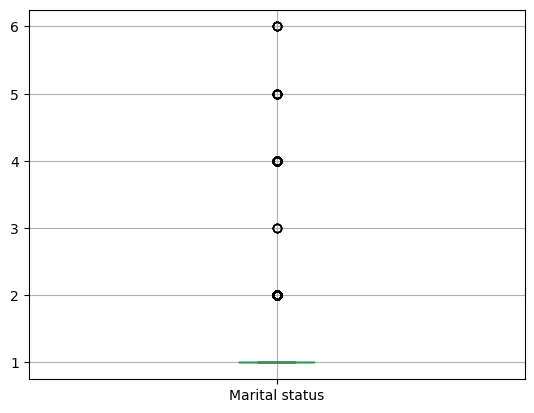

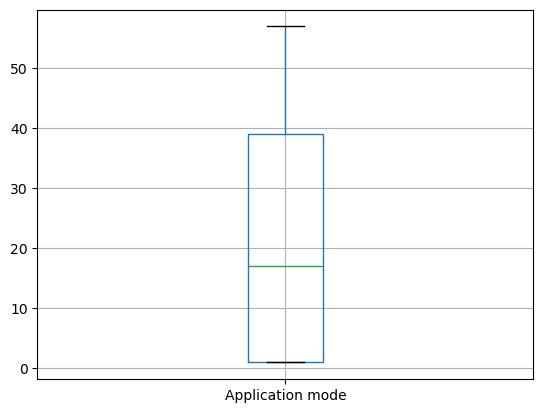

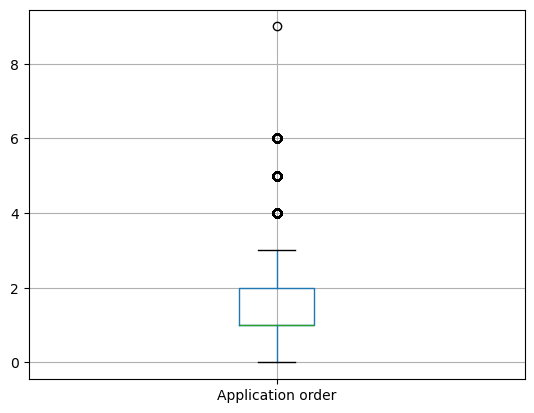

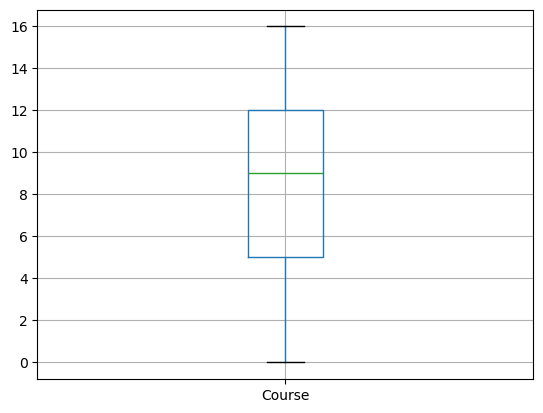

C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


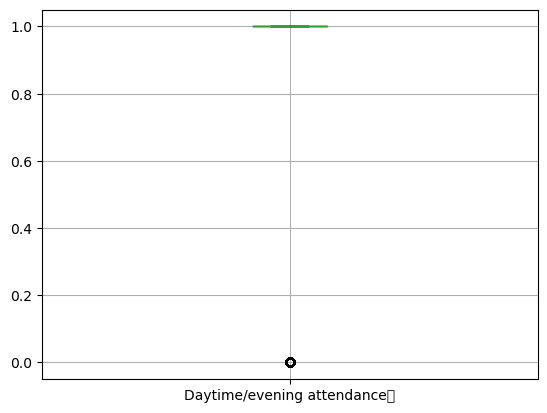

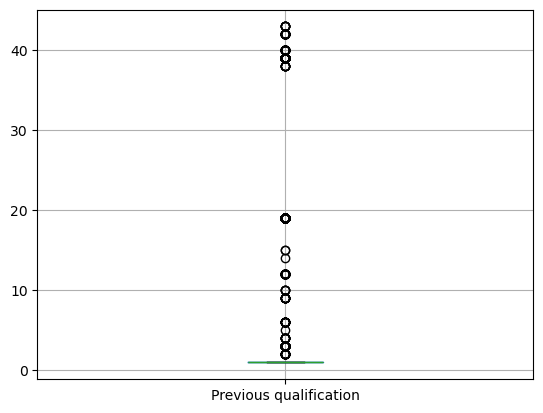

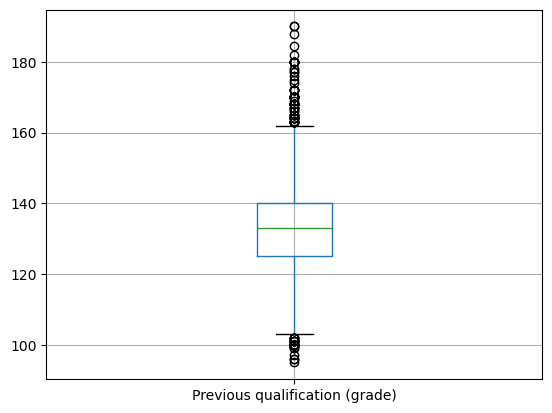

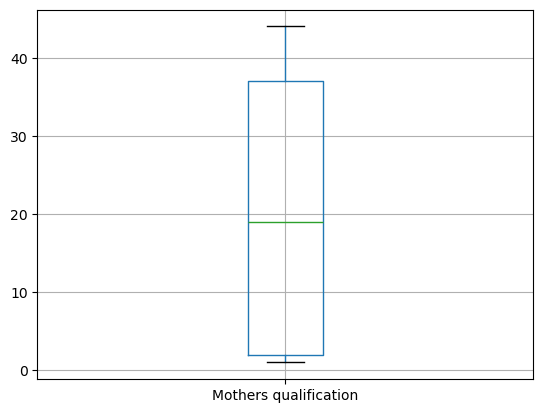

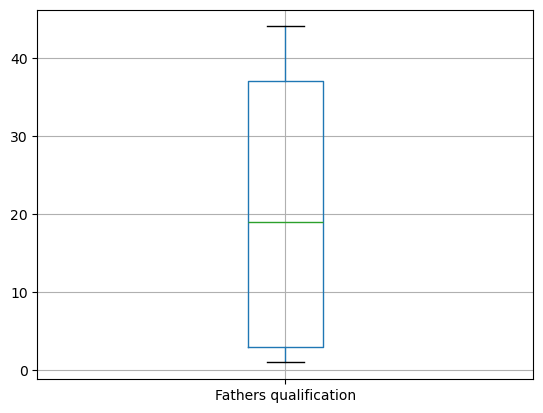

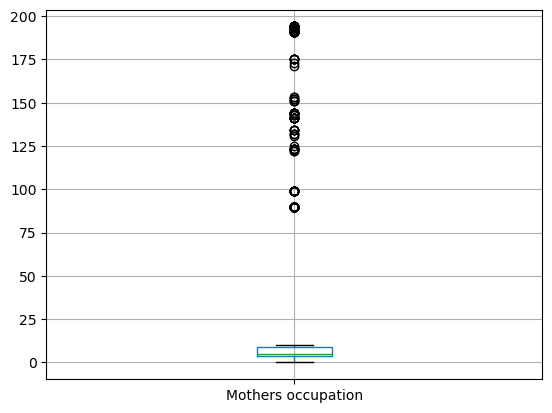

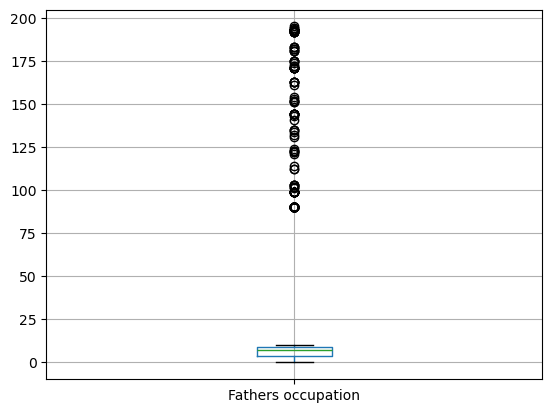

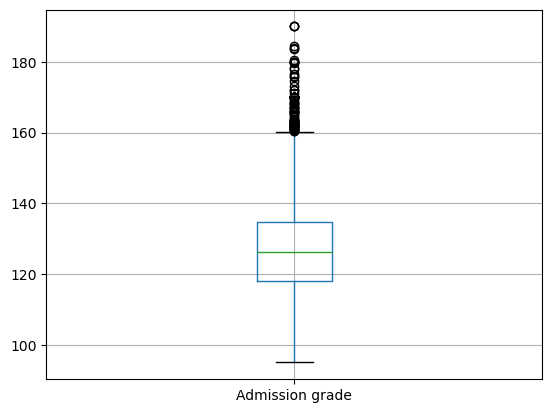

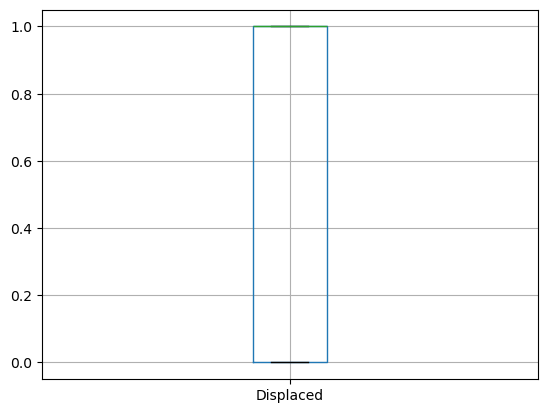

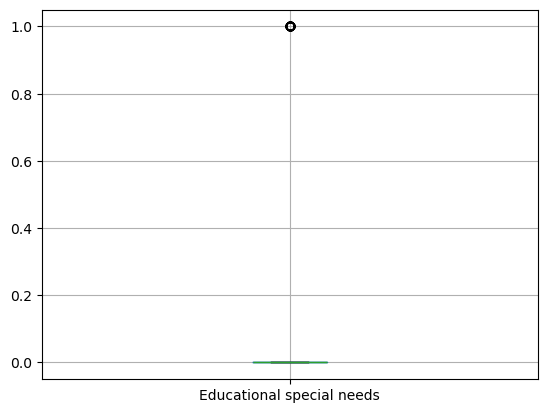

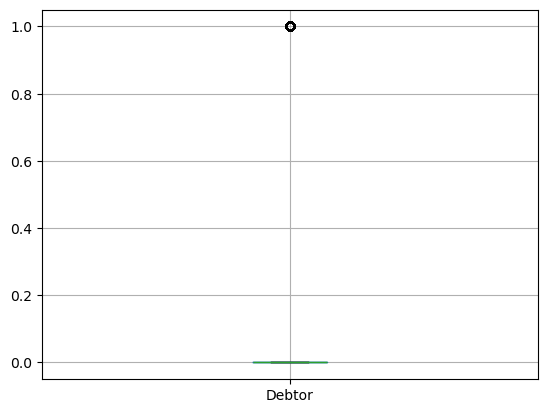

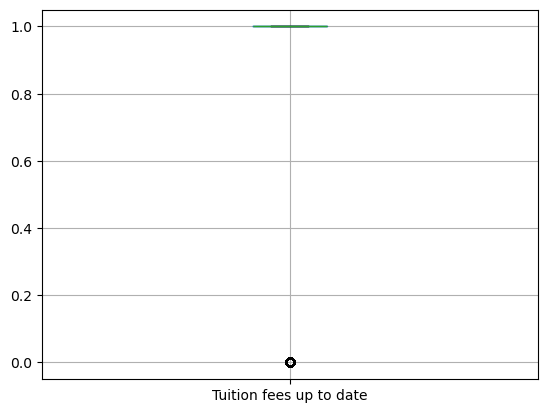

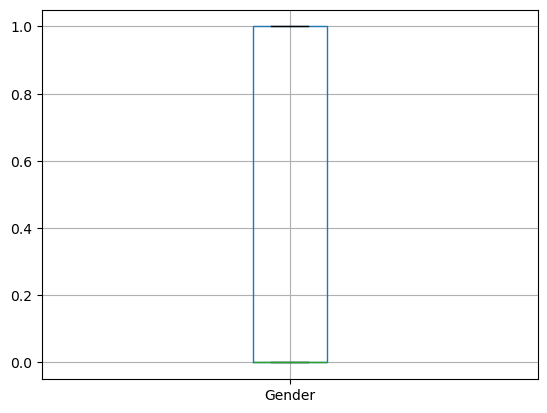

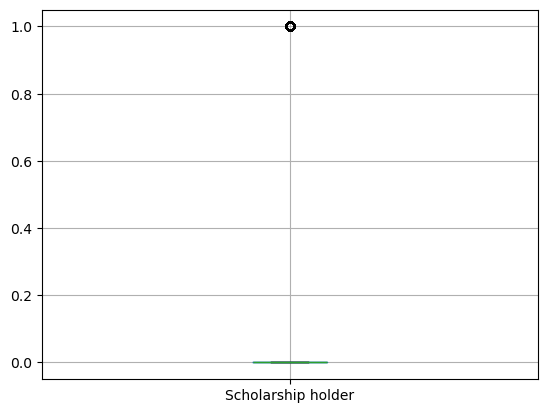

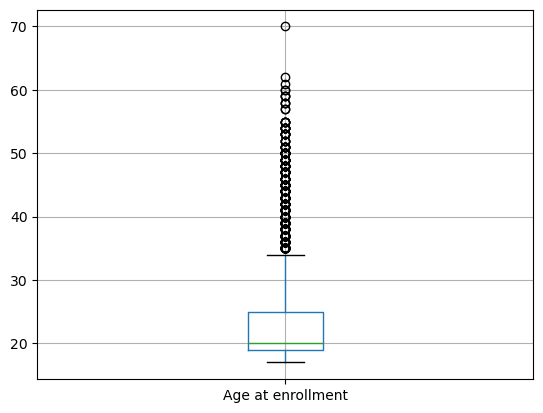

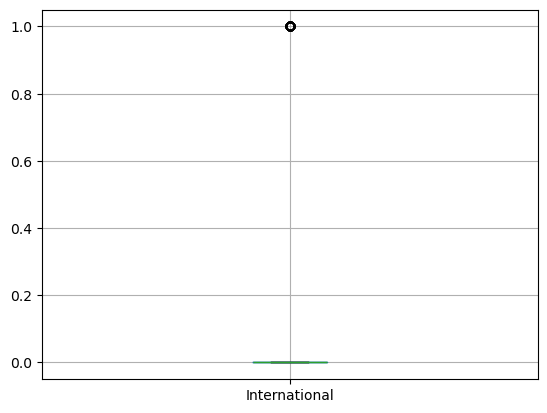

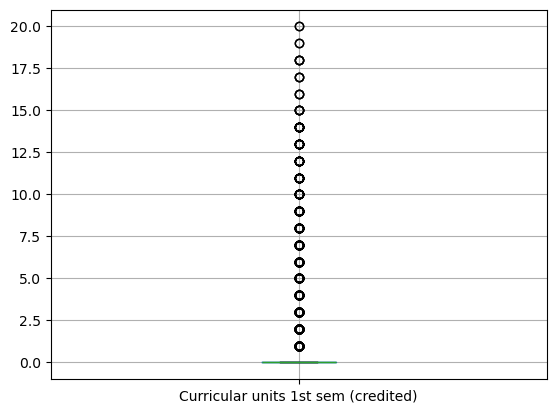

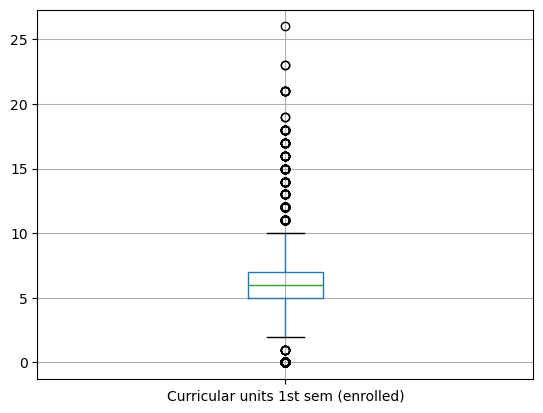

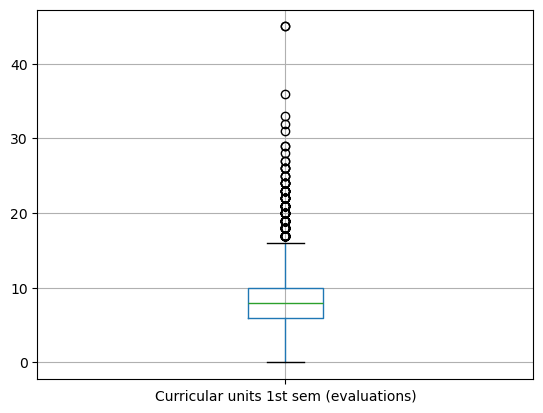

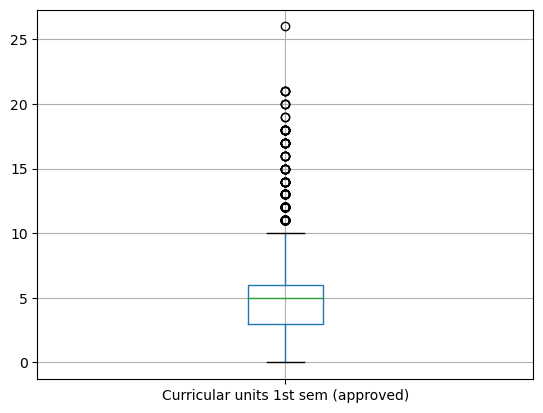

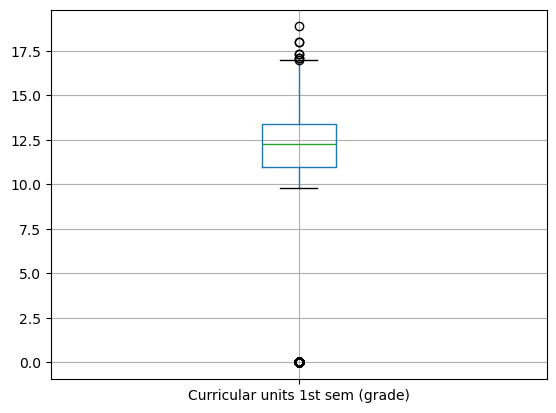

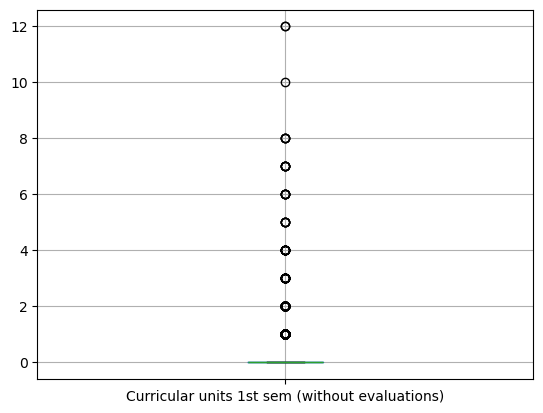

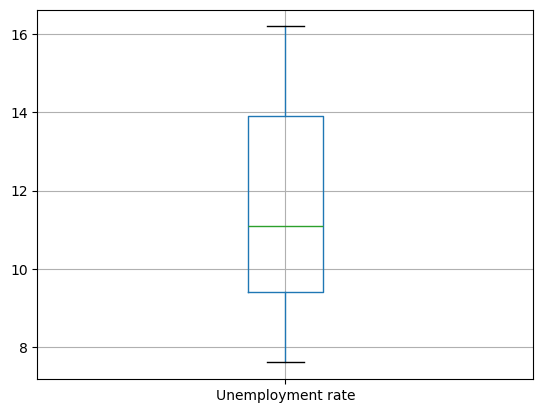

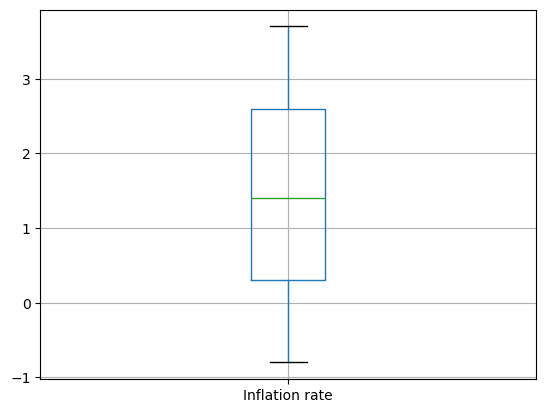

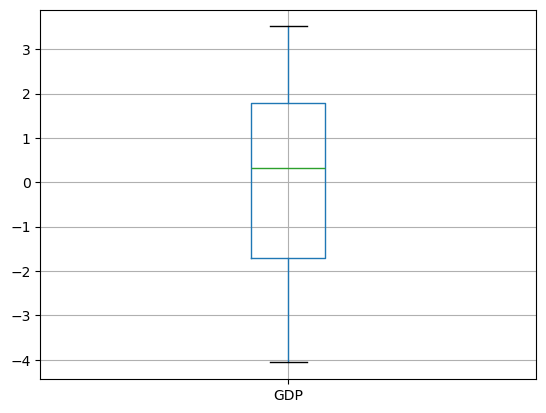

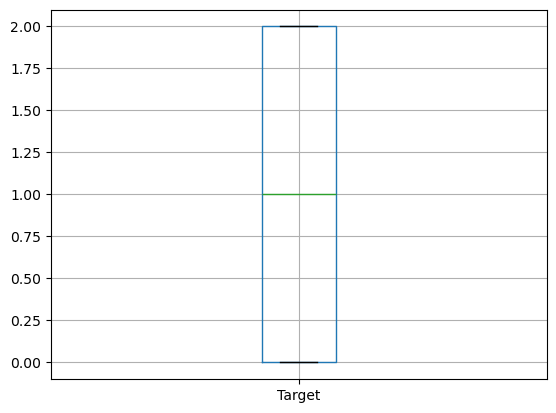

In [21]:
for column in df.columns:
    #print(column)
    plt.figure()
    df.boxplot([column])

No notable outliers observed in the boxplot so no columns need to be removed/fixed

## Feature engineering

In [22]:
#ensure all features contribute equally to the model regardless of unit/scale

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit and transform the DataFrame
df= pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Mothers qualification,Fathers qualification,Mothers occupation,...,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0.0,0.285714,0.555556,0.0625,1.0,0.0,0.284211,0.418605,0.255814,0.025773,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.372093,0.488889,0.766182,0.0
1,0.0,0.250000,0.111111,0.6250,1.0,0.0,0.684211,0.000000,0.046512,0.015464,...,0.0,0.230769,0.133333,0.230769,0.741722,0.0,0.732558,0.111111,0.640687,1.0
2,0.0,0.000000,0.555556,0.2500,1.0,0.0,0.284211,0.837209,0.837209,0.046392,...,0.0,0.230769,0.000000,0.000000,0.000000,0.0,0.372093,0.488889,0.766182,0.0
3,0.0,0.285714,0.222222,0.8750,1.0,0.0,0.284211,0.860465,0.837209,0.025773,...,0.0,0.230769,0.177778,0.230769,0.711447,0.0,0.209302,0.000000,0.124174,1.0
4,0.2,0.678571,0.111111,0.1250,0.0,0.0,0.052632,0.837209,0.860465,0.046392,...,0.0,0.230769,0.200000,0.192308,0.653422,0.0,0.732558,0.111111,0.640687,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,0.0,0.000000,0.666667,0.8750,1.0,0.0,0.315789,0.000000,0.000000,0.025773,...,0.0,0.230769,0.155556,0.192308,0.720530,0.0,0.918605,0.800000,0.000000,1.0
4420,0.0,0.000000,0.222222,0.8750,1.0,0.0,0.263158,0.000000,0.000000,0.046392,...,0.0,0.230769,0.133333,0.230769,0.635762,0.0,0.406977,0.311111,0.803170,0.0
4421,0.0,0.000000,0.111111,0.6875,1.0,0.0,0.621053,0.837209,0.837209,0.046392,...,0.0,0.269231,0.177778,0.269231,0.790066,0.0,0.732558,0.111111,0.640687,0.0
4422,0.0,0.000000,0.111111,0.5000,1.0,0.0,0.894737,0.837209,0.837209,0.036082,...,0.0,0.192308,0.111111,0.192308,0.731126,0.0,0.209302,0.000000,0.124174,1.0


# Machine Learning

## Importing libraries

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## Preparing the data

In [24]:
y = df['Target']  # 'Target' is the continuous target variable
X = df.drop('Target', axis=1)

## Creating training and testing sets

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

#Check the shape of the data
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (3096, 29)
Testing features shape: (1328, 29)
Training target shape: (3096,)
Testing target shape: (1328,)


## Linear Regression Model

In [26]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)  

y_pred_lr = linear_regression.predict(X_test) #lr for linear regression

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Evaluation Metrics:")
print(f"Mean Absolute Error: {mae_lr:.4f}")
print(f"Mean Squared Error: {mse_lr:.4f}")
print(f"Root Mean Squared Error: {rmse_lr:.4f}")
print(f"R-squared: {r2_lr:.4f}")

Linear Regression Evaluation Metrics:
Mean Absolute Error: 0.2437
Mean Squared Error: 0.0954
Root Mean Squared Error: 0.3088
R-squared: 0.5197


C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Decision tree regression model

In [27]:
tree_reg = DecisionTreeRegressor(random_state=101)
tree_reg.fit(X_train, y_train)

y_pred_dt = tree_reg.predict(X_test) #dt for decision tree

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt, squared=False)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Evaluation Metrics:")
print(f"Mean Absolute Error: {mae_dt:.4f}")
print(f"Mean Squared Error: {mse_dt:.4f}")
print(f"Root Mean Squared Error: {rmse_dt:.4f}")
print(f"R-squared: {r2_dt:.4f}")

Decision Tree Regressor Evaluation Metrics:
Mean Absolute Error: 0.2372
Mean Squared Error: 0.1747
Root Mean Squared Error: 0.4180
R-squared: 0.1201


C:\Users\darag\anaconda3\envs\AIClass\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
